<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°1 de TPS

Vamos con el set up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Item A



### Punto 1

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

Reviso que se hayan cargado bien los datos:

In [3]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


### Punto 2


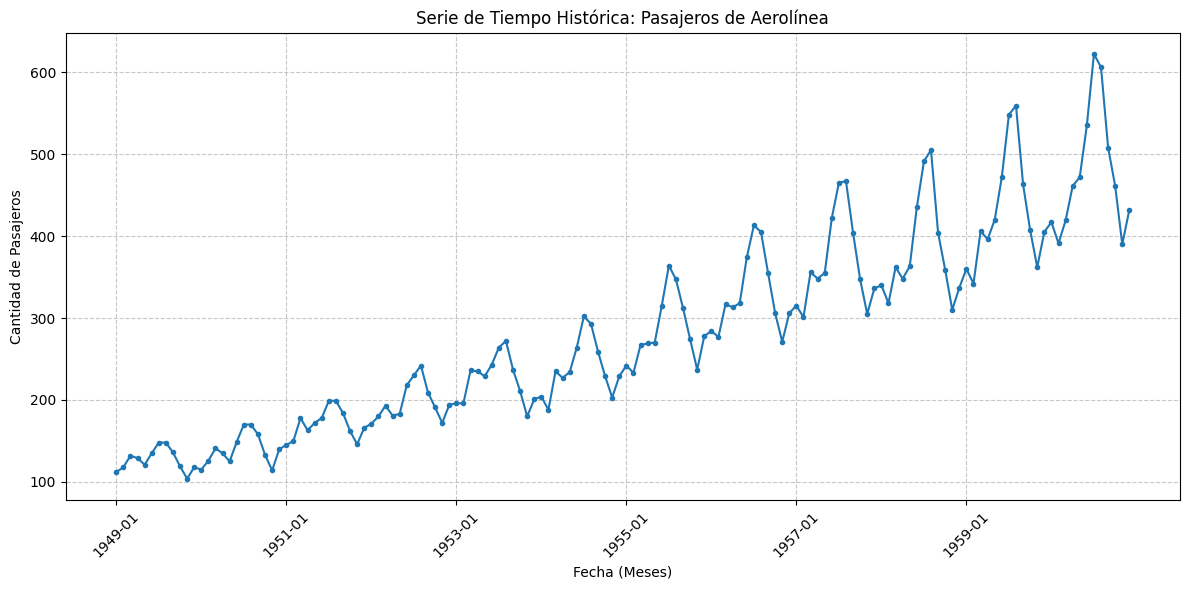

In [4]:
# Configuro el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Grafico la serie
# Uso df['Month'] para el eje X y df['Passengers'] para el eje Y
plt.plot(df['Month'], df['Passengers'], color='tab:blue', marker='.', linestyle='-')

# Agrego los nombres en los ejes y título
plt.xlabel('Fecha (Meses)')
plt.ylabel('Cantidad de Pasajeros')
plt.title('Serie de Tiempo Histórica: Pasajeros de Aerolínea')

# Mejoro la legibilidad del eje X (mostrando un año de por medio)
plt.xticks(df['Month'][::24], rotation=45)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Se está analizando el gráfico de la cantidad de pasajeros por mes de una aerolínea entre enero de 1949 y diciembre de 1960. A partir de la observación inicial, se puede identificar una tendencia creciente en la cantidad promedio de pasajeros a lo largo de los años, lo que indica que el volumen total de viajes fue aumentando con el tiempo.

Asimismo, se observan picos y caídas en distintos momentos de la serie. Sin embargo, a partir del gráfico no es posible identificar con precisión a qué meses corresponden esos máximos y mínimos. Contar con esa información permitiría analizar si existen meses en los que, históricamente, la demanda de viajes aéreos es mayor o menor que en otros.

Por este motivo, en la siguiente celda de código se realizará un análisis orientado a identificar los meses con mayor y menor cantidad de pasajeros. Además de realizar el gráfico de la media móvil.


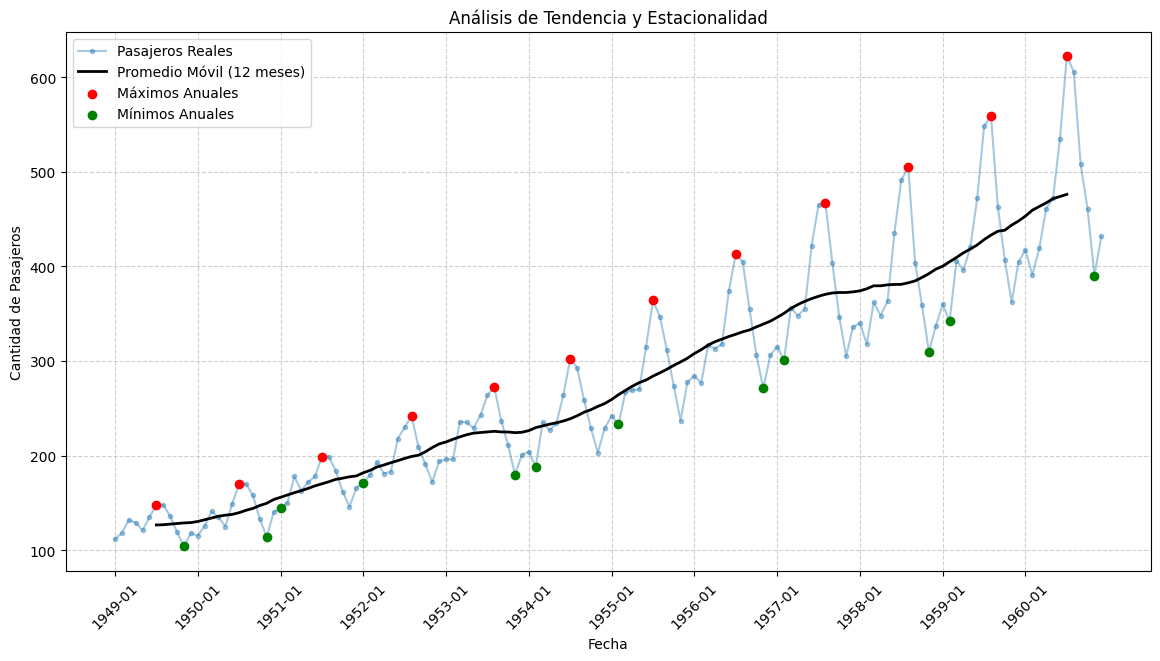

ANÁLISIS DE ESTACIONALIDAD HISTÓRICA
Meses de mayor demanda (Picos):
  * Julio: fue el pico máximo en 7 años.
  * Agosto: fue el pico máximo en 5 años.

Meses de menor demanda (Valles):
  * Noviembre: fue el punto más bajo en 6 años.
  * Febrero: fue el punto más bajo en 4 años.
  * Enero: fue el punto más bajo en 2 años.


In [5]:
# --- ANÁLISIS DE TENDENCIA (Punto a.2) ---

# -- Aplico un Promedio Móvil (Moving Average) para "suavizar" la serie: --

# 1. window=12: Promedia un año completo para eliminar el "ruido" de la estacionalidad (subas y bajas mensuales).
# 2. center=True: Centra el promedio en el mes del medio (mes 6 de 12) para que la línea no se desfase en el tiempo.
# 3. Resultado: Obtengo la tendencia real de crecimiento, ignorando los picos de vacaciones.
df['Promedio_Movil'] = df['Passengers'].rolling(window=12, center=True).mean()

# -- Busco los picos máximos y mínimos por año --
# Extraigo el año de la columna Month para agrupar
df['Year'] = df['Month'].str[:4]
max_per_year = df.loc[df.groupby('Year')['Passengers'].idxmax()]
min_per_year = df.loc[df.groupby('Year')['Passengers'].idxmin()]

# -- Grafico los resultados --
plt.figure(figsize=(14, 7))
plt.plot(df['Month'], df['Passengers'], label='Pasajeros Reales', alpha=0.4, color='tab:blue', marker='.')
plt.plot(df['Month'], df['Promedio_Movil'], label='Promedio Móvil (12 meses)', color='black', linewidth=2)

# Marco los picos
plt.scatter(max_per_year['Month'], max_per_year['Passengers'], color='red', label='Máximos Anuales', zorder=5)
plt.scatter(min_per_year['Month'], min_per_year['Passengers'], color='green', label='Mínimos Anuales', zorder=5)

plt.title('Análisis de Tendencia y Estacionalidad')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks(df['Month'][::12], rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# -- Imprimo los resultados: --
# Diccionario para pasar de número a nombre de mes
nombres_meses = {
    '01': 'Enero', '02': 'Febrero', '03': 'Marzo', '04': 'Abril',
    '05': 'Mayo', '06': 'Junio', '07': 'Julio', '08': 'Agosto',
    '09': 'Septiembre', '10': 'Octubre', '11': 'Noviembre', '12': 'Diciembre'
}

print("ANÁLISIS DE ESTACIONALIDAD HISTÓRICA")

# Proceso los máximos
print("Meses de mayor demanda (Picos):")
max_counts = max_per_year['Month'].str[5:].value_counts()
for mes_num, cant in max_counts.items():
    print(f"  * {nombres_meses[mes_num]}: fue el pico máximo en {cant} años.")

print("\nMeses de menor demanda (Valles):")
min_counts = min_per_year['Month'].str[5:].value_counts()
for mes_num, cant in min_counts.items():
    print(f"  * {nombres_meses[mes_num]}: fue el punto más bajo en {cant} años.")

Como se puede observar en los últimos resultados, se aprecia una clara tendencia creciente en la cantidad de pasajeros a lo largo de los 12 años analizados.

Por otro lado, a partir del análisis de los meses con mayor y menor cantidad de pasajeros, se puede inferir que estos datos probablemente corresponden a un país del hemisferio norte (posiblemente Estados Unidos). Durante los meses de verano (junio, julio y agosto) se registra un mayor número de viajes en avión, lo que podría explicarse por el período de vacaciones. En cambio, durante el invierno la demanda disminuye, con una caída particularmente marcada en noviembre. Esto podría deberse a que muchas personas evitan viajar en ese mes mientras se preparan para las fiestas de fin de año; posteriormente, en diciembre, la demanda vuelve a incrementarse levemente debido a celebraciones como Navidad y al inicio del período vacacional. Además, es razonable suponer que, en los meses más fríos, en general disminuye la disposición de las personas a viajar.

### Punto 3

Bueno, para el punto 3 del item a, el objetivo es transformar la serie de tiempo (una sola columna de datos) en una matriz de entrenamiento que el modelo de regresión lineal pueda entender.

Primero hay que tener en cuenta que la serie de datos tiene un comportamiento estacional de 12 meses. Es decir, lo que ocurre en un mes muchas veces está relacionado con lo que ocurrió durante el año anterior. Por esta razón, no conviene tratar cada dato como si fuera completamente independiente de los demás.

Para poder entrenar un modelo de predicción, es necesario transformar esta serie temporal (que es simplemente una lista de valores a lo largo del tiempo) en un conjunto de datos que el modelo pueda utilizar para aprender. Para lograrlo se utiliza una técnica llamada ventana deslizante (sliding window).

La idea es bastante simple. En lugar de mirar un solo mes, se toman 12 meses consecutivos y se usan como información de entrada. Esos 12 meses funcionan como “pistas” que le permiten al modelo entender cómo viene evolucionando la serie. Luego, el mes siguiente (el número 13) se utiliza como el valor que el modelo debe intentar predecir.

Por ejemplo, el modelo observa los datos desde enero hasta diciembre de un año y, con esa información, intenta predecir cuántos pasajeros habrá en enero del año siguiente.

Una vez hecho esto, la ventana se mueve un mes hacia adelante y se repite el proceso. Ahora el modelo toma los datos desde febrero hasta enero del año siguiente, e intenta predecir el valor de febrero. Este procedimiento continúa avanzando mes a mes a lo largo de toda la serie.

De esta manera se generan muchas muestras de entrenamiento a partir de una única serie histórica. En cada nueva muestra, la mayoría de los meses se repiten (porque la ventana solo se mueve un mes), pero el objetivo a predecir cambia. Esto permite construir un conjunto de datos mucho más grande y útil para entrenar el modelo.

In [6]:
# --- CONSTRUCCIÓN DEL DATASET (Punto a.3) ---

# Pasamos los datos de la columna 'Passengers' a un array de NumPy
serie = df['Passengers'].values

X = []
y = []
ventana = 12  # Los 12 meses anteriores para predecir el siguiente

# Generamos los solapamientos
for i in range(len(serie) - ventana):
    # Tomamos desde i hasta i+12 como features (X)
    X.append(serie[i : i + ventana])
    # El valor en i+12 es nuestro objetivo o target (y)
    y.append(serie[i + ventana])

# Convertimos las listas en arrays de NumPy
X = np.array(X)
y = np.array(y)

# Verificamos las dimensiones
print(f"Dimensiones de la matriz de entrada (X): {X.shape}") # Debería ser (132, 12)
print(f"Dimensiones del vector de salida (y): {y.shape}")     # Debería ser (132,)

# Ejemplo de la primera muestra
print("\nPrimera muestra de entrenamiento:")
print(f"X[0] (Meses 1 al 12): {X[0]}")
print(f"y[0] (Mes 13): {y[0]}")

Dimensiones de la matriz de entrada (X): (132, 12)
Dimensiones del vector de salida (y): (132,)

Primera muestra de entrenamiento:
X[0] (Meses 1 al 12): [112 118 132 129 121 135 148 148 136 119 104 118]
y[0] (Mes 13): 115


## Item B


### Punto 1



En este punto se implementa el modelo que se va a usar para predecir la serie temporal a partir de los datos construidos en el punto anterior.  
El objetivo general es encontrar una función $\phi(X)$ que permita estimar una salida $Y$ a partir de una entrada $X$:

$$
\hat Y = \phi(X)
$$

En teoría, el regresor óptimo en el sentido de error cuadrático medio es la esperanza condicional:

$$
\phi(x) = \mathbb{E}[Y \mid X=x]
$$

Como esa función no es conocida, se la aproxima con un modelo lineal.

En este problema, para cada instante $t$ se toman como entrada los 12 meses anteriores y como salida el valor del mes actual:

$$
X_t = [y_{t-12}, y_{t-11}, \dots, y_{t-1}],
\qquad
Y_t = y_t
$$

De esta forma, el predictor propuesto es:

$$
\hat y_t = b + \sum_{k=1}^{12} w_k\, y_{t-k}
$$

donde $b$ y los coeficientes $w_k$ son parámetros desconocidos que se estiman a partir de los datos.

Es importante notar que no se busca un conjunto distinto de pesos para cada mes, sino un único conjunto global de parámetros que funcione lo mejor posible para todas las muestras de entrenamiento.  
Para eso, los parámetros se obtienen minimizando el error cuadrático total:

$$
\min_{b,w}\sum_t (\hat y_t - y_t)^2
$$

En otras palabras: se quiere predecir el próximo valor como una combinación lineal de los últimos 12 valores, aprendiendo a partir de los datos cuánto pesa cada uno.

En forma matricial, si se agrega una columna de unos a la matriz de datos, la solución de mínimos cuadrados es:

$$
\theta^{\star} = ( X^T ⋅ X)^{-1} X^T y
$$

donde $\theta = [b, w_1, \dots, w_{12}]^T$.





In [7]:
class LinearRegression:
    def __init__(self):
        # Atributo para guardar los parámetros encontrados (w y b)
        self.params_ = None

    def fit(self, X, y):
        """
        Etapa de entrenamiento: calcula los pesos óptimos usando la solución matricial.
        """
        # 1. Aumenta X: se agrega una columna de unos al principio para b
        # np.c_ concatena por columnas. Se crea una columna de unos del mismo alto que X.
        X_aug = np.c_[np.ones(X.shape[0]), X]

        # 2. Se implementa la solución matricial óptima
        # @: multiplica matrices, .T: da la transpuesta
        self.params_ = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y

    def predict(self, X):
        """
        Etapa de testeo: genera predicciones basadas en los parámetros aprendidos.
        """
        # Se aumenta la matriz X de entrada para que coincida con los pesos
        X_aug = np.c_[np.ones(X.shape[0]), X]

        return X_aug @ self.params_

    def mean_squared_error(self, X, y):
        """
        Cómputo del error cuadrático medio (MSE)[cite: 24].
        """
        y_pred = self.predict(X)
        # MSE = promedio de (valor_real - valor_predicho)^2
        error = np.mean((y - y_pred) ** 2)
        return error

### Punto 2


In [8]:
# 1. Se crea el objeto
modelo_matricial = LinearRegression()

# 2. Se entrena el modelo con los datos X e y del punto A.3
modelo_matricial.fit(X, y)

# 3. Se extrae params_
pesos = modelo_matricial.params_

print(f"Ordenada al origen (b): {pesos[0]:.4f}")
print(f"Pesos de los 12 meses (w): \n{pesos[1:]}")
print("-" * 30)

# 4. Calcular el Error Cuadrático Medio de entrenamiento
mse_train = modelo_matricial.mean_squared_error(X, y)
rmse = np.sqrt(mse_train)
print(f"Error Cuadrático Medio (MSE) de entrenamiento: {mse_train:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")

Ordenada al origen (b): 9.4369
Pesos de los 12 meses (w): 
[ 0.61268285  0.31794891 -0.25287341  0.27933163 -0.26873158  0.1790373
 -0.19835968  0.23357866 -0.21532935  0.19438396 -0.27158819  0.44370462]
------------------------------
Error Cuadrático Medio (MSE) de entrenamiento: 182.5376
Raíz del Error Cuadrático Medio (RMSE): 13.5106


Ahora hago el gráfico para comparar la predicción con la serie original.

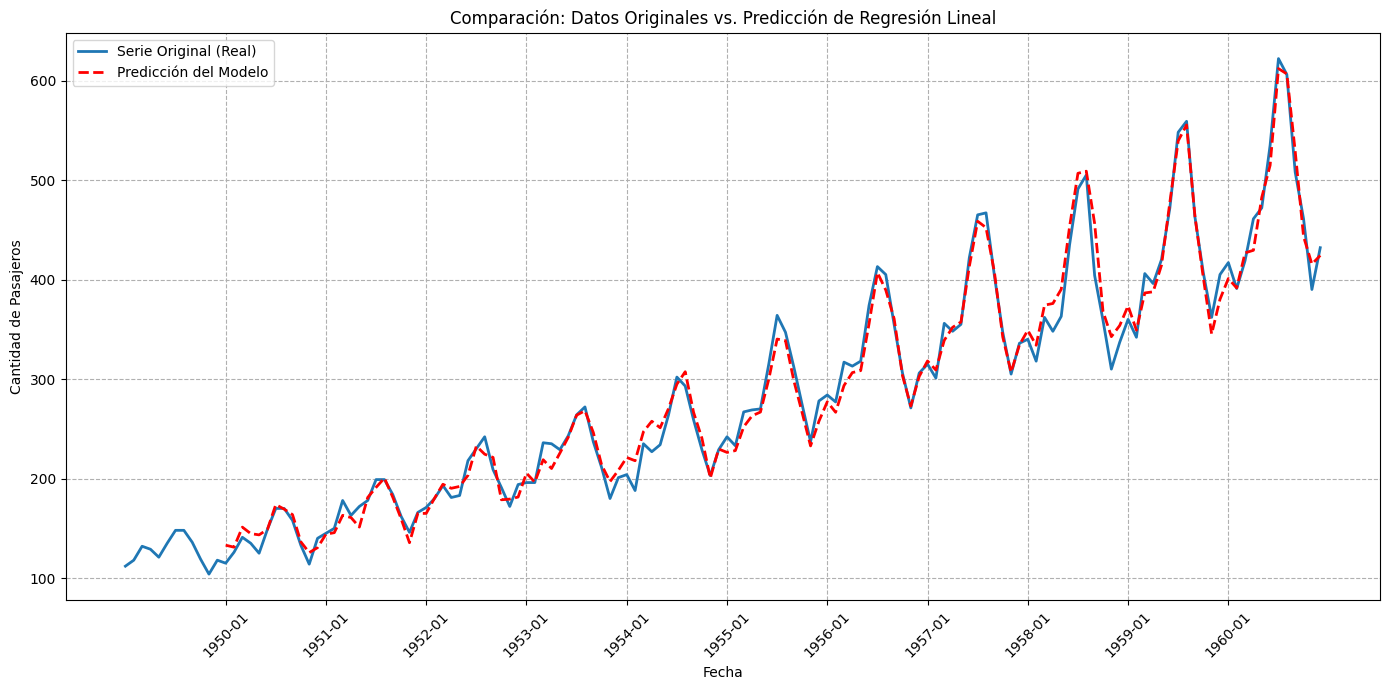

Error Cuadrático Medio (MSE) de entrenamiento: 182.5376
Raíz del Error Cuadrático Medio (RMSE): 13.5106


In [9]:
# 1. Se generan las predicciones para todo el conjunto
y_pred = modelo_matricial.predict(X)

# 2. Se arma el gráfico
plt.figure(figsize=(14, 7))

# Se grafica la serie original
plt.plot(df['Month'], df['Passengers'], label='Serie Original (Real)', color='tab:blue', linewidth=2)

# Se grafica la predicción del modelo
plt.plot(df['Month'][12:], y_pred, label='Predicción del Modelo', color='red', linestyle='--', linewidth=2)

plt.title('Comparación: Datos Originales vs. Predicción de Regresión Lineal')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks(df['Month'][12::12], rotation=45) # Marcas cada año
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# Calculo de MSE y RMSE
mse_final = modelo_matricial.mean_squared_error(X, y)
rmse_final = np.sqrt(mse_final)
print(f"Error Cuadrático Medio (MSE) de entrenamiento: {mse_final:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_final:.4f}")

Del gráfico se observa que la predicción comienza un año después del inicio de la serie. Esto tiene sentido, ya que para estimar un mes el modelo necesita disponer de los 12 meses anteriores. Por eso, el primer mes que puede predecirse es enero de 1950, usando como entrada los datos de 1949, que es justamente lo que se ve en el gráfico.

Por otro lado, analizando el error cuadrático medio, dado que el MSE está expresado en pasajeros$^2$, su interpretación directa no resulta tan intuitiva. Por eso es más útil considerar el RMSE (Root Mean Squared Error), es decir, la raíz del error cuadrático medio, que vuelve a expresar el error en la misma unidad que la variable original (en este caso, cantidad de pasajeros, ya que es lo que estamos intentando estimar cada mes).

En este caso, el RMSE es alrededor de 13.5 pasajeros, es decird el orden de 14, lo que indica que el error típico de predicción mensual es aproximadamente de ese valor. En los primeros años de la serie, donde la cantidad de pasajeros es menor, ese error representa una fracción relativamente importante del valor real (prácticamente el \%10). Mientras que a medida que la serie crece, el mismo error absoluto pasa a representar un porcentaje menor.


### Punto 3

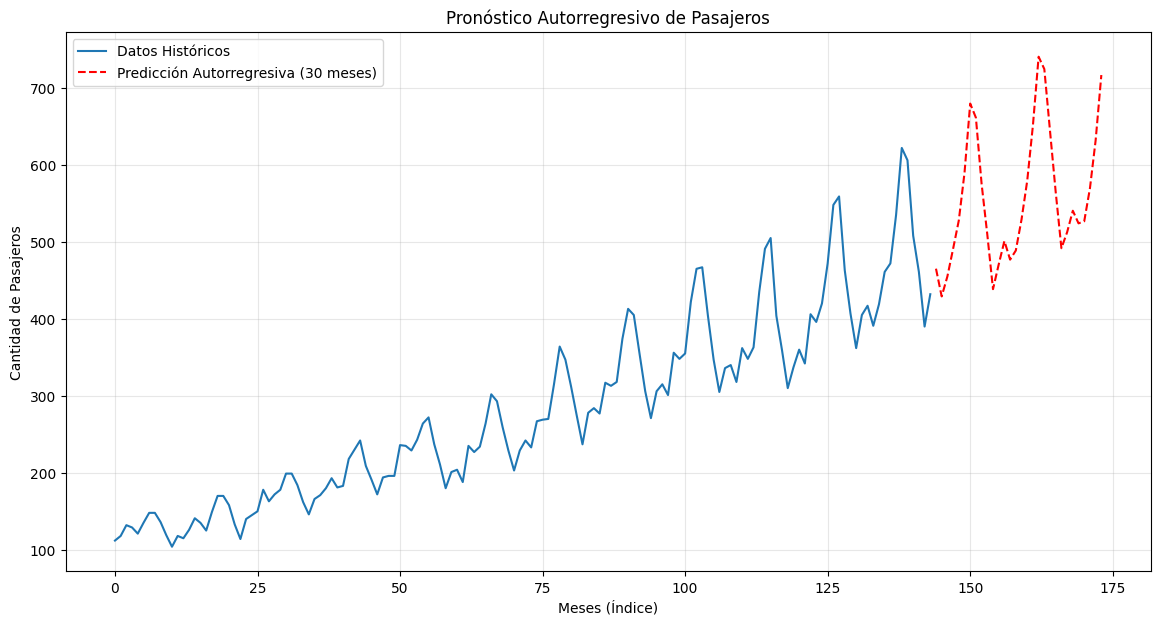

In [10]:
# 1. Preparar la semilla: los últimos 12 meses de la serie original
ultima_ventana = serie[-12:].reshape(1, -1)
predicciones_futuras = []

# 2. Bucle autorregresivo para 30 meses
for i in range(30):
    # Predecir el siguiente mes usando la ventana actual
    pred_mes = modelo_matricial.predict(ultima_ventana)

    # Guardar la predicción (usamos [0] porque predict devuelve un array)
    predicciones_futuras.append(pred_mes[0])

    # Actualizar la ventana:
    # Se quita el primer mes y agregamos la nueva predicción al final
    nueva_ventana = np.append(ultima_ventana[0, 1:], pred_mes)
    ultima_ventana = nueva_ventana.reshape(1, -1)

# 3. Graficar para interpretar
plt.figure(figsize=(14, 7))

# Serie original completa
meses_originales = np.arange(len(serie))
plt.plot(meses_originales, serie, label='Datos Históricos', color='tab:blue')

# Serie predicha (empieza donde termina la original)
meses_futuros = np.arange(len(serie), len(serie) + 30)
plt.plot(meses_futuros, predicciones_futuras, label='Predicción Autorregresiva (30 meses)',
         color='red', linestyle='--')

plt.title('Pronóstico Autorregresivo de Pasajeros')
plt.xlabel('Meses (Índice)')
plt.ylabel('Cantidad de Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Una vez entrenado el modelo, se lo utiliza para predecir los próximos 30 meses de manera iterativa.
Para obtener la primera predicción se toman los últimos 12 valores reales disponibles de la serie.

Luego, el valor predicho se incorpora a la serie y se utiliza como parte de la entrada para estimar el siguiente mes. Repitiendo este procedimiento se generan los 30 valores futuros.
  
Debe tenerse en cuenta que, a medida que avanza la predicción, los errores pueden acumularse, porque el modelo comienza a alimentarse con sus propias salidas. Por lo que, en general, las primeras predicciones futuras suelen ser más fiables que las más lejanas.

### Punto 4

La base de datos construida en este trabajo no está formada por muestras independientes ya que cada muestra se obtiene tomando una ventana de 12 meses consecutivos de una misma serie temporal, por lo que dos muestras vecinas comparten la mayor parte de sus datos.

En efecto, si:

$$
X_t = [y_{t-12}, y_{t-11}, \dots, y_{t-1}]
$$

Entonces la muestra siguiente es:

$$
X_{t+1} = [y_{t-11}, y_{t-10}, \dots, y_t]
$$

Ambas comparten 11 de sus 12 componentes.  
Esto muestra que no puede asumirse independencia entre observaciones.

Por lo tanto, no se cumplen estrictamente los supuestos clásicos de muestras i.i.d (muestran independientes e indénticamente distribuidas). Sin embargo, esto no invalida el enfoque; en una serie temporal la dependencia entre valores consecutivos es justamente la información que se busca explotar para predecir el futuro.

En este sentido, el modelo sigue siendo útil como predictor lineal, aunque la interpretación estadística del error debe hacerse con cuidado, ya que las muestras no provienen de observaciones independientes.

## Item C


En el ítem C no se modifica el predictor lineal utilizado en B; lo que cambia es el método de estimación de sus parámetros.

En lugar de obtenerlos directamente mediante la solución cerrada de mínimos cuadrados, ahora se los ajusta de manera iterativa usando gradiente descendente.

Para eso, se define una función de costo ($J(\theta)$), que mide el error cuadrático medio que comete el modelo al predecir los datos de entrenamiento:

$$
J(\theta)=\frac{1}{n}\|\tilde X ⋅\theta-y\|^2
$$

Donde ($J(\theta)$) representa el vector de parámetros del modelo, ($\tilde X$) es la matriz de entrada (incluyendo la columna asociada al sesgo) e \(y\) es el vector de valores reales.

La idea del gradiente descendente es ir corrigiendo esos parámetros paso a paso para disminuir el valor de ($J(\theta)$):

$$
\theta^{(t+1)}=\theta^{(t)}-\alpha \nabla J(\theta^{(t)})
$$

Donde ($\alpha$) es el *learning rate*, es decir, el tamaño del paso de corrección en cada iteración.  

Si ($\alpha$) es muy chico, la convergencia es lenta; si es muy grande, el algoritmo puede no converger.

Además, las entradas se normalizan para que todas queden en una escala comparable, lo que mejora el comportamiento numérico del algoritmo y facilita la convergencia.

### Punto 1


In [11]:
class LinearRegression:
    def __init__(self):
        """
        Inicializa el objeto de regresión. Los parámetros se guardan en el atributo params_.
        """
        self.params_ = None
        self.error_history = []

    def fit(self, X, y):
        """
        Calcula la solución analítica exacta mediante la Ecuación Normal.
        Agrega una columna de unos a la matriz X para incluir el término de bias (b).
        """
        X_aug = np.c_[np.ones(X.shape[0]), X]
        # w = (X^T * X)^-1 * X^T * y
        self.params_ = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y

    def fit_gradient(self, X, y, learning_rate, epochs=10000):
        """
        Optimiza los parámetros utilizando el algoritmo de Gradiente Descendente.
        Actualiza los pesos de forma iterativa siguiendo la regla: theta = theta - alpha * gradiente.
        """
        n_samples, n_features = X.shape
        X_aug = np.c_[np.ones(n_samples), X]

        # Inicializa los parámetros en cero
        self.params_ = np.zeros(X_aug.shape[1])
        self.error_history = []

        for i in range(epochs):
            # Calcula la predicción actual y el error
            y_pred = X_aug @ self.params_
            error = y_pred - y

            # Calcula el gradiente de la función de costo MSE
            # Gradiente = (2/n) * X^T * (Xw - y)
            gradient = (2 / n_samples) * (X_aug.T @ error)

            # Actualiza los parámetros utilizando el learning rate (alpha)
            self.params_ = self.params_ - learning_rate * gradient

            # Almacena el costo actual para monitorear la convergencia
            mse = np.mean(error**2)
            self.error_history.append(mse)

            # Evalúa el criterio de parada si la variación es despreciable
            if i > 0 and abs(self.error_history[-2] - self.error_history[-1]) < 1e-9:
                print(f"Convergencia alcanzada en la iteración: {i}")
                break

    def predict(self, X):
        """
        Realiza predicciones sobre nuevos datos. Requiere aumentar la matriz de entrada.
        """
        X_aug = np.c_[np.ones(X.shape[0]), X]
        return X_aug @ self.params_

    def mean_squared_error(self, X, y):
        """
        Calcula el Riesgo Empírico del modelo mediante el Error Cuadrático Medio.
        """
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)

### Punto 2

Una vez redefinida la clase para entrenar el modelo mediante gradiente descendente, se repiten los mismos procedimientos realizados en los puntos 1 y 2 del ítem B.

In [12]:
# Se calculan media y desvío de las 12 columnas de entrada
mu_X = np.mean(X, axis=0)
sigma_X = np.std(X, axis=0)

# Se normalizan las features X
X_norm = (X - mu_X) / sigma_X

# El vector y se mantiene original (pasajeros reales)
y_real = y

print("Features X normalizadas. El target y se mantiene en escala original.")

Features X normalizadas. El target y se mantiene en escala original.


En esta sección se busca elegir un valor razonable para el learning rate $\alpha$ sin hacerlo completamente a prueba y error.  

La idea es usar la forma matemática de la función de costo para tener una referencia de qué tan grande o qué tan chico conviene que sea el paso del gradiente descendente.

Para regresión lineal, la función de costo es:

$$
J(\theta)=\frac{1}{n}\|\tilde X\theta-y\|^2
$$

Su curvatura está dada por la Hessiana:

$$
H=\frac{2}{n}\tilde X^T  \tilde X
$$

A partir de los autovalores de esta matriz se calcula un $\alpha$ teórico conveniente:

$$
\alpha_{\text{opt}}=\frac{2}{\lambda_{\max}+\lambda_{\min}}
$$

Donde \lambda_{\max} es el autovalor más grande de la matriz y \lambda_{\min} el menor. También se busca el límite de estabilidad:

$$
\alpha < \frac{2}{\lambda_{\max}}
$$

La interpretación es sencilla: si $\alpha$ es muy chico, el algoritmo avanza demasiado lento; si es muy grande, puede pasarse del mínimo y no converger.
  
Por eso, en lugar de elegirlo al azar, se usa esta cuenta como guía.

Todo esto se hace sobre los datos normalizados, ya que normalizar mejora la escala de las variables y ayuda a que el descenso por gradiente funcione de manera más estable.

In [13]:
# 1. Calculamos la Hessiana de los datos normalizados
# H = (2/n) * X^T * X
H = (2 / X_norm.shape[0]) * (X_norm.T @ X_norm)

# 2. Obtenemos los autovalores
eigenvalues = np.linalg.eigvals(H)
lambda_max = np.max(eigenvalues)
lambda_min = np.min(eigenvalues)

# 3. Calculamos el alpha óptimo según la teórica
alpha_opt = 2 / (lambda_max + lambda_min)

print(f"Alpha óptimo teórico: {alpha_opt:.4f}")
print(f"Límite de divergencia (2/lambda_max): {2/lambda_max:.4f}")

Alpha óptimo teórico: 0.0976
Límite de divergencia (2/lambda_max): 0.0976


Con el valor de $\alpha$ elegido previamente, se entrena el modelo mediante gradiente descendente durante un número fijo de iteraciones.  

En cada paso, los parámetros se actualizan para intentar reducir el error cuadrático del modelo.

Para analizar si el método está funcionando correctamente, se grafica la evolución de la función de costo a lo largo de las iteraciones.  

Si la curva desciende y luego tiende a estabilizarse, esto indica que el algoritmo está convergiendo. En cambio, si oscila demasiado o crece, puede ser señal de que el learning rate elegido no es adecuado.

Se usa escala logarítmica en el eje vertical para apreciar mejor cómo disminuye el error durante el entrenamiento.

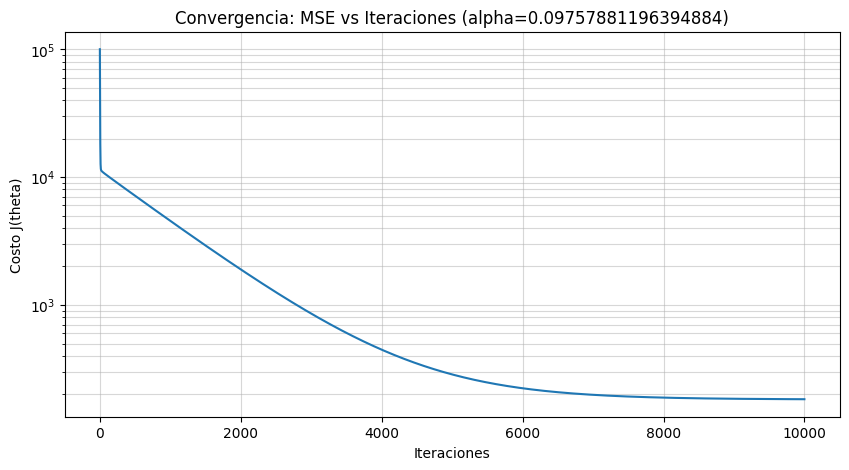

In [14]:
alpha = alpha_opt # Learning rate ajustado para y sin normalizar
modelo_gd = LinearRegression()

# Entrenamiento iterativo
modelo_gd.fit_gradient(X_norm, y_real, learning_rate=alpha, epochs=10000)

# Graficamos la curva de aprendizaje (Punto c.2)
plt.figure(figsize=(10, 5))
plt.plot(modelo_gd.error_history)
plt.yscale('log')
plt.title(f'Convergencia: MSE vs Iteraciones (alpha={alpha})')
plt.xlabel('Iteraciones')
plt.ylabel('Costo J(theta)')
plt.grid(True, which="both", alpha=0.5)
plt.show()

Del gráfico de la función de costo puede observarse que el error disminuye de manera monótona a medida que avanzan las iteraciones.  

Esto indica que el algoritmo de gradiente descendente está convergiendo correctamente para el valor de learning rate elegido.

La caída inicial es muy pronunciada, lo que muestra que en las primeras iteraciones el modelo corrige rápidamente los parámetros y reduce gran parte del error.  

Luego, la disminución del costo se vuelve más lenta hasta tender a estabilizarse, señal de que el algoritmo se está acercando a una solución de equilibrio.

Además, no se observan oscilaciones fuertes ni divergencia, por lo que el valor de $\alpha$ utilizado resulta adecuado para este problema.

In [18]:
# 1. Se extraen los parámetros del modelo entrenado por Gradiente Descendente
parametros_gd = modelo_gd.params_
bias_gd = parametros_gd[0]
pesos_gd = parametros_gd[1:]

# 2. Se calculan las métricas de error sobre los datos de entrenamiento
mse_gd = modelo_gd.mean_squared_error(X_norm, y_real)
rmse_gd = np.sqrt(mse_gd)

# 3. Se muestran los resultados por pantalla
print("RESULTADOS DEL ENTRENAMIENTO (GRADIENTE DESCENDENTE)")
print("-" * 50)
print(f"Bias (b) encontrado: {bias_gd:.4f}")
print(f"Pesos (w): {pesos_gd[1:]}")
print("-" * 50)
print(f"Mean Squared Error (MSE): {mse_gd:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gd:.4f}")
print("-" * 50)

# 4. Comparación rápida con el modelo matricial (Punto B)
# Esto permite verificar si el Gradiente Descendente llegó al mismo mínimo global
print(f"Diferencia de MSE vs Modelo Matricial: {abs(mse_gd - mse_final):.8f}")

RESULTADOS DEL ENTRENAMIENTO (GRADIENTE DESCENDENTE)
--------------------------------------------------
Bias (b) encontrado: 294.2652
Primeros 3 pesos (w): [ 33.48750551 -26.68973237  29.37275963 -28.59637858  18.94087506
 -21.51267659  25.96242504 -24.69896651  22.27425189 -31.44698874
  50.94220217]
--------------------------------------------------
Mean Squared Error (MSE): 183.5147
Root Mean Squared Error (RMSE): 13.5468
--------------------------------------------------
Diferencia de MSE vs Modelo Matricial: 0.97718954


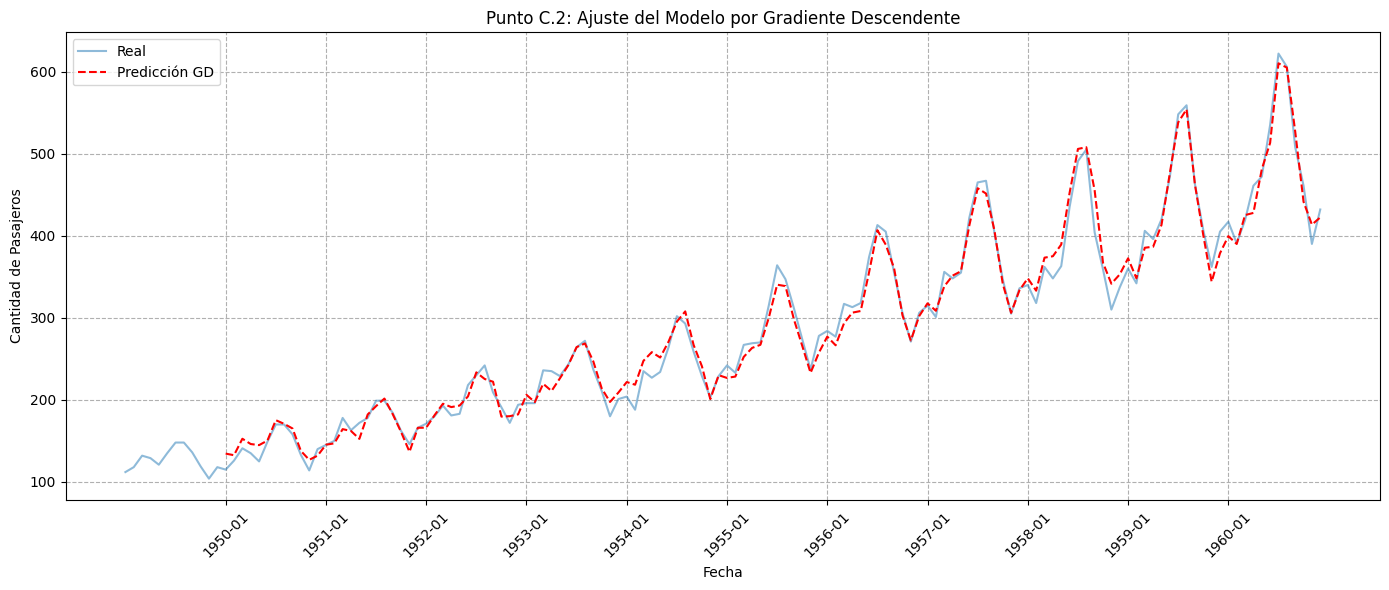

In [16]:
# Para predecir sobre los datos de entrenamiento, usamos X_norm
y_pred_gd = modelo_gd.predict(X_norm)

plt.figure(figsize=(14, 6))
plt.plot(df['Month'], df['Passengers'], label='Real', alpha=0.5)
plt.plot(df['Month'][12:], y_pred_gd, label='Predicción GD', color='red', linestyle='--')
plt.title('Punto C.2: Ajuste del Modelo por Gradiente Descendente')

plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks(df['Month'][12::12], rotation=45) # Marcas cada año
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()


Los próximos 30 meses:

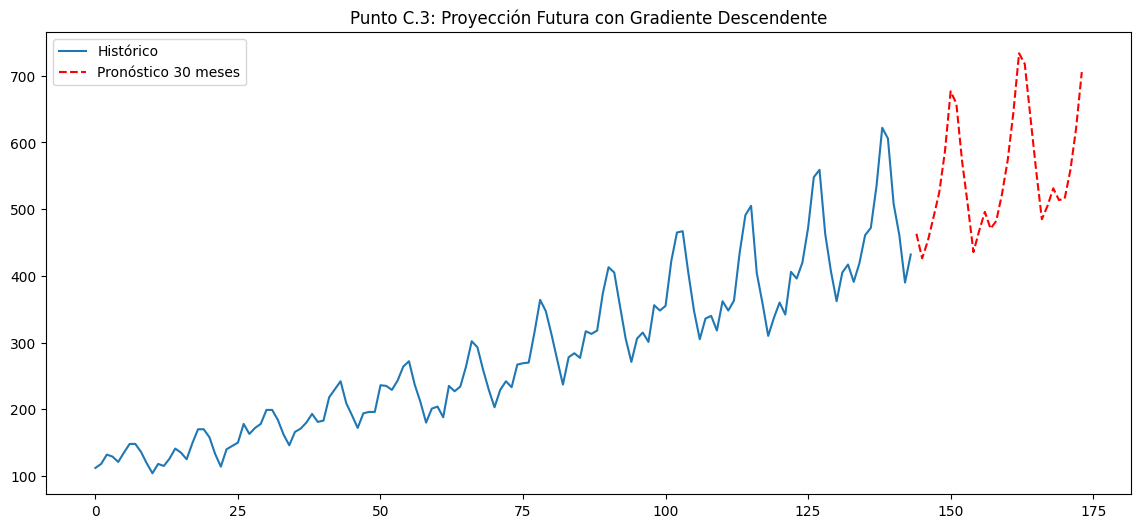

In [17]:
# Semilla inicial: últimos 12 meses reales
ventana_actual = serie[-12:]
predicciones_futuras_gd = []

for _ in range(30):
    # 1. Normalizar la ventana usando los valores guardados
    ventana_norm = (ventana_actual - mu_X) / sigma_X
    ventana_norm = ventana_norm.reshape(1, -1)

    # 2. Predecir (el resultado ya sale en escala real de pasajeros)
    pred = modelo_gd.predict(ventana_norm)[0]
    predicciones_futuras_gd.append(pred)

    # 3. Actualizar ventana: sacar el primero, meter la predicción al final
    ventana_actual = np.append(ventana_actual[1:], pred)

# Graficamos la proyección
plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(serie)), serie, label='Histórico')
plt.plot(np.arange(len(serie), len(serie)+30), predicciones_futuras_gd, color='red', linestyle='--',label='Pronóstico 30 meses')
plt.title('Punto C.3: Proyección Futura con Gradiente Descendente')
plt.legend()
plt.show()